# Label Coverage Analysis

Determine the optimal sample boundary (Tmag cutoff + plx cutoff) for the Stellar World Model by scanning label coverage rates across brightness and parallax ranges.

Current sample: `processed/df_final.csv`, 6,654 stars (Tmag < 7, plx > 10 mas).  
Current label coverage: rotation=5.4%, flare=2.8%, transit=0.4%, quiet=92.4% — too sparse for meaningful SSL evaluation.

---
## Section 0 — Imports & Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from astroquery.mast import Catalogs

try:
    plt.style.use('seaborn-v0_8-whitegrid')
except OSError:
    plt.style.use('ggplot')

plt.rcParams.update({'font.size': 12, 'figure.dpi': 100})

# Project root detection via CLAUDE.md marker
def find_project_root() -> Path:
    p = Path.cwd()
    for _ in range(10):
        if (p / "CLAUDE.md").exists():
            return p
        p = p.parent
    raise FileNotFoundError("CLAUDE.md not found — cannot determine project root")

ROOT = find_project_root()
print(f"Project root: {ROOT}")

# Load reference sample
df_final = pd.read_csv(ROOT / "processed" / "df_final.csv")
print(f"Reference sample (df_final): {len(df_final)} stars  (Tmag < 7, plx > 10 mas)")

Project root: c:\git_repo\Stellar-World-Model
Reference sample (df_final): 34343 stars  (Tmag < 7, plx > 10 mas)


---
## Section 1 — Pull Broad TIC Candidate Set

Query TIC v8 for Tmag < 13, plx > 1 mas. Skip query if `processed/tic_candidates_broad.csv` already exists.

Loaded tic_candidates_batch_0_7.csv  (39,703 rows)
Loaded tic_candidates_batch_7_8.csv  (65,213 rows)
Loaded tic_candidates_batch_8_9.csv  (151,900 rows)
Loaded tic_candidates_batch_9_10.csv  (337,873 rows)

Loaded from batch CSVs: 594,689 rows total

df_broad shape: (594689, 7)
Tmag range: [0.03, 10.00]
plx range:  [1.00, 768.50]


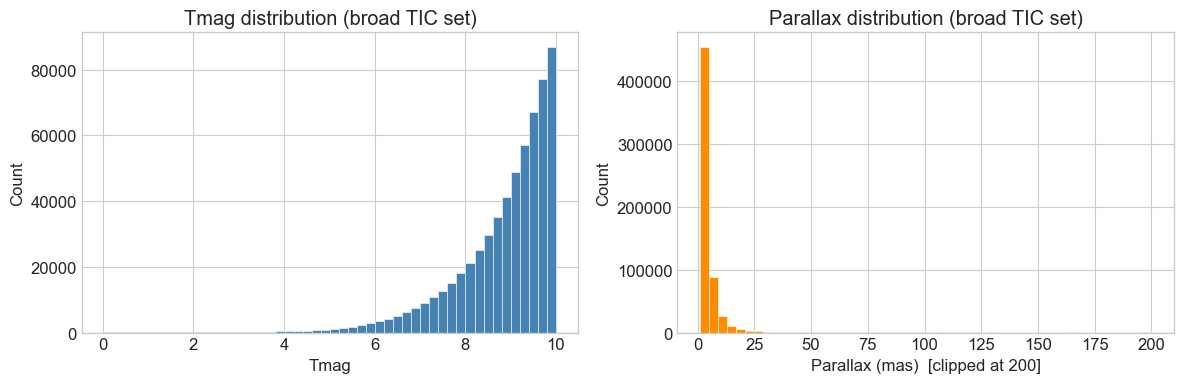

In [2]:
BATCH_CSV_PATHS = [
    ROOT / "processed" / "tic_candidates_batch_0_7.csv",
    ROOT / "processed" / "tic_candidates_batch_7_8.csv",
    ROOT / "processed" / "tic_candidates_batch_8_9.csv",
    ROOT / "processed" / "tic_candidates_batch_9_10.csv",
]

batch_dfs: list[pd.DataFrame] = []
for path in BATCH_CSV_PATHS:
    if path.exists():
        df_b = pd.read_csv(path)
        batch_dfs.append(df_b)
        print(f"Loaded {path.name}  ({len(df_b):,} rows)")
    else:
        print(f"WARNING: {path.name} not found")

if batch_dfs:
    df_broad = pd.concat(batch_dfs, ignore_index=True)
    print(f"\nLoaded from batch CSVs: {len(df_broad):,} rows total")
else:
    raise FileNotFoundError("No batch CSV files found. Expected tic_candidates_batch_*.csv in processed/")

print(f"\ndf_broad shape: {df_broad.shape}")
print(f"Tmag range: [{df_broad['Tmag'].min():.2f}, {df_broad['Tmag'].max():.2f}]")
print(f"plx range:  [{df_broad['plx'].min():.2f}, {df_broad['plx'].max():.2f}]")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_broad['Tmag'].dropna(), bins=50, color='steelblue', edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Tmag')
axes[0].set_ylabel('Count')
axes[0].set_title('Tmag distribution (broad TIC set)')
axes[1].hist(df_broad['plx'].dropna().clip(upper=200), bins=50, color='darkorange', edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Parallax (mas)  [clipped at 200]')
axes[1].set_ylabel('Count')
axes[1].set_title('Parallax distribution (broad TIC set)')
plt.tight_layout()
plt.show()

---
## Section 2 — Load Label Catalogs

Load TARS (rotation), flatwrm2 Table 3 (flares), and TOI (transits). Build O(1) lookup sets — same pattern as `build_variability_labels.py`.

In [3]:
from tenacity import retry, retry_if_exception_type, stop_after_attempt, wait_exponential, RetryError
import requests.exceptions

# ── TARS (rotation) ─────────────────────────────────────────────────────────
# Column names confirmed in build_variability_labels.py: TICID, adopted_period
tars_path = ROOT / "data" / "tars_table_2.feather"
df_tars = pd.read_feather(tars_path)
print(f"TARS rows: {len(df_tars)}  |  columns: {df_tars.columns.tolist()}")

TARS_TIC_COL = "TICID"
TARS_PERIOD_COL = "adopted_period"
assert TARS_TIC_COL in df_tars.columns, f"Expected '{TARS_TIC_COL}' in TARS"
tars_tic_set: set[int] = set(df_tars[TARS_TIC_COL].astype(int).unique())
print(f"TARS unique TIC IDs with rotation periods: {len(tars_tic_set)}")

# ── flatwrm2 Table 3 (flares) ────────────────────────────────────────────────
# Column name confirmed in build_variability_labels.py: TIC
flare_path = ROOT / "data" / "Table3_flare_catalog.csv"
df_flare = pd.read_csv(flare_path)
print(f"\nflatwrm2 rows: {len(df_flare)}  |  columns: {df_flare.columns.tolist()}")

FLARE_TIC_COL = "TIC"
assert FLARE_TIC_COL in df_flare.columns, f"Expected '{FLARE_TIC_COL}' in flatwrm2"
flare_tic_set: set[int] = set(df_flare[FLARE_TIC_COL].astype(int).unique())
print(f"flatwrm2 unique TIC IDs with flares: {len(flare_tic_set)}")

# ── TOI (transits) ───────────────────────────────────────────────────────────
# Try reading existing variability_labels_star.csv first; fall back to re-querying NASA EA
toi_tic_set: set[int] = set()
toi_source = ""

existing_labels_path = ROOT / "labels" / "variability_labels_star.csv"
if existing_labels_path.exists():
    df_var = pd.read_csv(existing_labels_path)
    if "transit" in df_var.columns and "tic_id" in df_var.columns:
        toi_tic_set = set(df_var.loc[df_var["transit"] == 1, "tic_id"].astype(int).unique())
        toi_source = f"existing variability_labels_star.csv ({len(df_var)} rows)"
        print(f"\nTOI loaded from {toi_source}")
        print(f"Stars with transit=1: {len(toi_tic_set)}")
        print("NOTE: This covers only the 6,654 reference stars. For the broad set we re-query NASA EA below.")

# Always re-query NASA EA so TOI lookup covers the full broad TIC set
print("\nRe-querying NASA Exoplanet Archive TOI for full coverage...")

@retry(
    stop=stop_after_attempt(3),
    wait=wait_exponential(multiplier=1, min=5, max=60),
    retry=retry_if_exception_type((requests.exceptions.ConnectionError,
                                   requests.exceptions.Timeout,
                                   requests.exceptions.ChunkedEncodingError,
                                   ConnectionError, TimeoutError, Exception)),
    reraise=False,
)
def _fetch_toi() -> pd.DataFrame:
    from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
    toi = NasaExoplanetArchive.query_criteria(
        table="toi",
        select="tid,toi,tfopwg_disp",
    ).to_pandas()
    return toi[toi["tfopwg_disp"] != "FP"].copy()

try:
    df_toi = _fetch_toi()
    toi_tic_set = set(df_toi["tid"].astype(int).unique())
    print(f"TOI table: {len(df_toi)} rows after FP filter  |  unique TIC IDs: {len(toi_tic_set)}")
except (RetryError, Exception) as e:
    if toi_tic_set:
        print(f"NASA EA query failed ({type(e).__name__}). Falling back to existing labels CSV with {len(toi_tic_set)} TIC IDs.")
    else:
        print(f"NASA EA query failed ({type(e).__name__}) and no fallback available. transit labels will be all-zero.")

print(f"\nCatalog summary:")
print(f"  TARS (rotation) : {len(tars_tic_set):>7,} unique TIC IDs")
print(f"  flatwrm2 (flare): {len(flare_tic_set):>7,} unique TIC IDs")
print(f"  TOI (transit)   : {len(toi_tic_set):>7,} unique TIC IDs")

TARS rows: 944056  |  columns: ['TICID', 'dr2_source_id', 'dr3_source_id', 'ra', 'dec', 'pmra', 'pmdec', 'parallax', 'teff', 'Tmag', 'phot_g_mean_mag', 'phot_g_mean_mag_0', 'phot_bp_mean_mag', 'phot_bp_mean_mag_0', 'phot_rp_mean_mag', 'phot_rp_mean_mag_0', 'BpmRp0', 'extinction_a0', 'ruwe', 'non_single_star', 'adopted_period', 'adopted_period_unc', 'flag_multiple_periods', 'flag_possible_binary', 'final_n_contams', 'flag_doubled_period', 'n_secs', 'n_sec_ratio', 'median_amplitude', 'sectors', 'sector_periods', 'sector_sys_probs', 'sector_sig_probs', 'sector_match_probs', 'sector_alias_probs', 'sector_amplitudes']
TARS unique TIC IDs with rotation periods: 944056

flatwrm2 rows: 121895  |  columns: ['TIC', 'sector', 'peak_time', 'timescale', 'amplitude', 'ED', 'TESS_energy']
flatwrm2 unique TIC IDs with flares: 14408

TOI loaded from existing variability_labels_star.csv (6654 rows)
Stars with transit=1: 29
NOTE: This covers only the 6,654 reference stars. For the broad set we re-query N

---
## Section 3 — Cross-match & Label the Full Candidate Set

Assign `rotation`, `flare_ever`, `transit` binary labels via in-memory O(1) lookup. Result stays in memory as `df_labeled`.

In [4]:
tic_ids = df_broad['ID'].astype(int).values

df_labeled = df_broad.copy()
df_labeled['tic_id'] = tic_ids
df_labeled['rotation']  = df_labeled['tic_id'].isin(tars_tic_set).astype(int)
df_labeled['flare_ever'] = df_labeled['tic_id'].isin(flare_tic_set).astype(int)
df_labeled['transit']   = df_labeled['tic_id'].isin(toi_tic_set).astype(int)
df_labeled['any_label'] = ((df_labeled['rotation'] == 1) |
                           (df_labeled['flare_ever'] == 1) |
                           (df_labeled['transit'] == 1)).astype(int)

n = len(df_labeled)
r = df_labeled['rotation'].sum()
f = df_labeled['flare_ever'].sum()
t = df_labeled['transit'].sum()
a = df_labeled['any_label'].sum()

print(f"df_labeled: {n:,} stars (full broad set)")
print(f"  rotation=1  : {r:>6,}  ({100*r/n:.1f}%)")
print(f"  flare=1     : {f:>6,}  ({100*f/n:.1f}%)")
print(f"  transit=1   : {t:>6,}  ({100*t/n:.1f}%)")
print(f"  any_label=1 : {a:>6,}  ({100*a/n:.1f}%)")
print(f"  quiet       : {n-a:>6,}  ({100*(n-a)/n:.1f}%)")

df_labeled: 594,689 stars (full broad set)
  rotation=1  : 42,517  (7.1%)
  flare=1     :  2,918  (0.5%)
  transit=1   :    912  (0.2%)
  any_label=1 : 43,964  (7.4%)
  quiet       : 550,725  (92.6%)


---
## Section 4 — Coverage vs Tmag (1D scan)

Cumulative cutoffs from Tmag < 7 up to Tmag < 13, with plx > 1 mas fixed.

Coverage vs Tmag  (plx > 1.0 mas fixed)
Tmag_cutoff  N_stars  rotation%  flare%  transit%  any_label%  quiet%
        < 7    39699        3.7     0.5       0.1         4.2    95.8
        < 8   104905        5.4     0.6       0.1         5.8    94.2
        < 9   256801        6.3     0.6       0.2         6.7    93.3
       < 10   594649        7.1     0.5       0.2         7.4    92.6
       < 11   594689        7.1     0.5       0.2         7.4    92.6
       < 12   594689        7.1     0.5       0.2         7.4    92.6
       < 13   594689        7.1     0.5       0.2         7.4    92.6


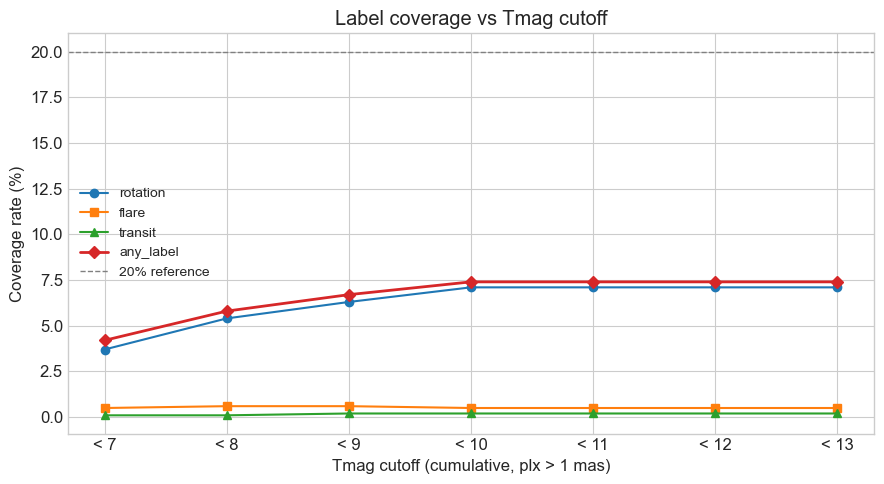

In [5]:
TMAG_CUTOFFS = [7, 8, 9, 10, 11, 12, 13]
PLX_FIXED = 1.0

rows_tmag = []
for cutoff in TMAG_CUTOFFS:
    sub = df_labeled[(df_labeled['Tmag'] < cutoff) & (df_labeled['plx'] > PLX_FIXED)]
    n_total = len(sub)
    if n_total == 0:
        continue
    n_rot   = sub['rotation'].sum()
    n_fla   = sub['flare_ever'].sum()
    n_tra   = sub['transit'].sum()
    n_any   = sub['any_label'].sum()
    n_quiet = n_total - n_any
    rows_tmag.append({
        'Tmag_cutoff': f'< {cutoff}',
        'N_stars':     n_total,
        'rotation%':   round(100 * n_rot   / n_total, 1),
        'flare%':      round(100 * n_fla   / n_total, 1),
        'transit%':    round(100 * n_tra   / n_total, 1),
        'any_label%':  round(100 * n_any   / n_total, 1),
        'quiet%':      round(100 * n_quiet / n_total, 1),
    })

df_tmag_scan = pd.DataFrame(rows_tmag)
print(f"Coverage vs Tmag  (plx > {PLX_FIXED} mas fixed)")
print(df_tmag_scan.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
cutoff_vals = TMAG_CUTOFFS[:len(df_tmag_scan)]
ax.plot(cutoff_vals, df_tmag_scan['rotation%'],  marker='o', label='rotation',   color='tab:blue')
ax.plot(cutoff_vals, df_tmag_scan['flare%'],      marker='s', label='flare',      color='tab:orange')
ax.plot(cutoff_vals, df_tmag_scan['transit%'],    marker='^', label='transit',    color='tab:green')
ax.plot(cutoff_vals, df_tmag_scan['any_label%'],  marker='D', label='any_label',  color='tab:red', linewidth=2)
ax.axhline(20, color='gray', linestyle='--', linewidth=1, label='20% reference')
ax.set_xlabel('Tmag cutoff (cumulative, plx > 1 mas)')
ax.set_ylabel('Coverage rate (%)')
ax.set_title('Label coverage vs Tmag cutoff')
ax.legend(fontsize=10)
ax.set_xticks(cutoff_vals)
ax.set_xticklabels([f'< {c}' for c in cutoff_vals])
plt.tight_layout()
plt.show()

---
## Section 5 — Coverage vs Parallax (1D scan)

Cumulative plx cutoffs from > 1 up to > 50 mas, with Tmag < 11 fixed.

Coverage vs plx  (Tmag < 11.0 fixed)
plx_cutoff  N_stars  rotation%  flare%  transit%  any_label%  quiet%
       > 1   594689        7.1     0.5       0.2         7.4    92.6
       > 2   349798       12.2     0.8       0.3        12.6    87.4
       > 5   139202       15.0     1.9       0.5        15.8    84.2
      > 10    41222       19.0     3.7       0.9        20.7    79.3
      > 20     9701       19.7     6.9       1.3        23.1    76.9
      > 50     1256       15.4    14.3       1.8        23.3    76.7


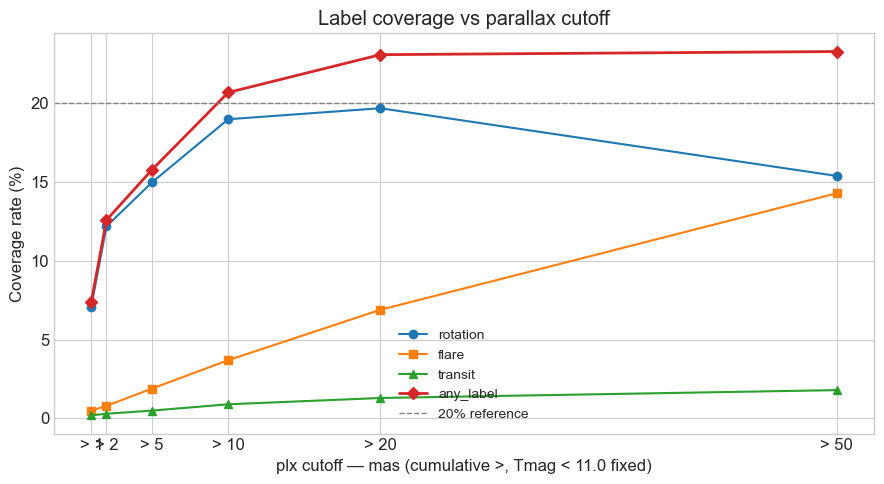

In [6]:
PLX_CUTOFFS  = [1, 2, 5, 10, 20, 50]
TMAG_FIXED   = 11.0

rows_plx = []
for cutoff in PLX_CUTOFFS:
    sub = df_labeled[(df_labeled['Tmag'] < TMAG_FIXED) & (df_labeled['plx'] > cutoff)]
    n_total = len(sub)
    if n_total == 0:
        continue
    n_rot   = sub['rotation'].sum()
    n_fla   = sub['flare_ever'].sum()
    n_tra   = sub['transit'].sum()
    n_any   = sub['any_label'].sum()
    n_quiet = n_total - n_any
    rows_plx.append({
        'plx_cutoff': f'> {cutoff}',
        'N_stars':    n_total,
        'rotation%':  round(100 * n_rot   / n_total, 1),
        'flare%':     round(100 * n_fla   / n_total, 1),
        'transit%':   round(100 * n_tra   / n_total, 1),
        'any_label%': round(100 * n_any   / n_total, 1),
        'quiet%':     round(100 * n_quiet / n_total, 1),
    })

df_plx_scan = pd.DataFrame(rows_plx)
print(f"Coverage vs plx  (Tmag < {TMAG_FIXED} fixed)")
print(df_plx_scan.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(PLX_CUTOFFS[:len(df_plx_scan)], df_plx_scan['rotation%'],  marker='o', label='rotation',   color='tab:blue')
ax.plot(PLX_CUTOFFS[:len(df_plx_scan)], df_plx_scan['flare%'],      marker='s', label='flare',      color='tab:orange')
ax.plot(PLX_CUTOFFS[:len(df_plx_scan)], df_plx_scan['transit%'],    marker='^', label='transit',    color='tab:green')
ax.plot(PLX_CUTOFFS[:len(df_plx_scan)], df_plx_scan['any_label%'],  marker='D', label='any_label',  color='tab:red', linewidth=2)
ax.axhline(20, color='gray', linestyle='--', linewidth=1, label='20% reference')
ax.set_xlabel(f'plx cutoff — mas (cumulative >, Tmag < {TMAG_FIXED} fixed)')
ax.set_ylabel('Coverage rate (%)')
ax.set_title('Label coverage vs parallax cutoff')
ax.legend(fontsize=10)
ax.set_xticks(PLX_CUTOFFS[:len(df_plx_scan)])
ax.set_xticklabels([f'> {c}' for c in PLX_CUTOFFS[:len(df_plx_scan)]])
plt.tight_layout()
plt.show()

---
## Section 6 — 2D Coverage Heatmap

Grid: Tmag cutoffs [7, 8, 9, 10, 11] × plx cutoffs [1, 2, 5, 10]. Three side-by-side heatmaps (rotation, flare, any_label).

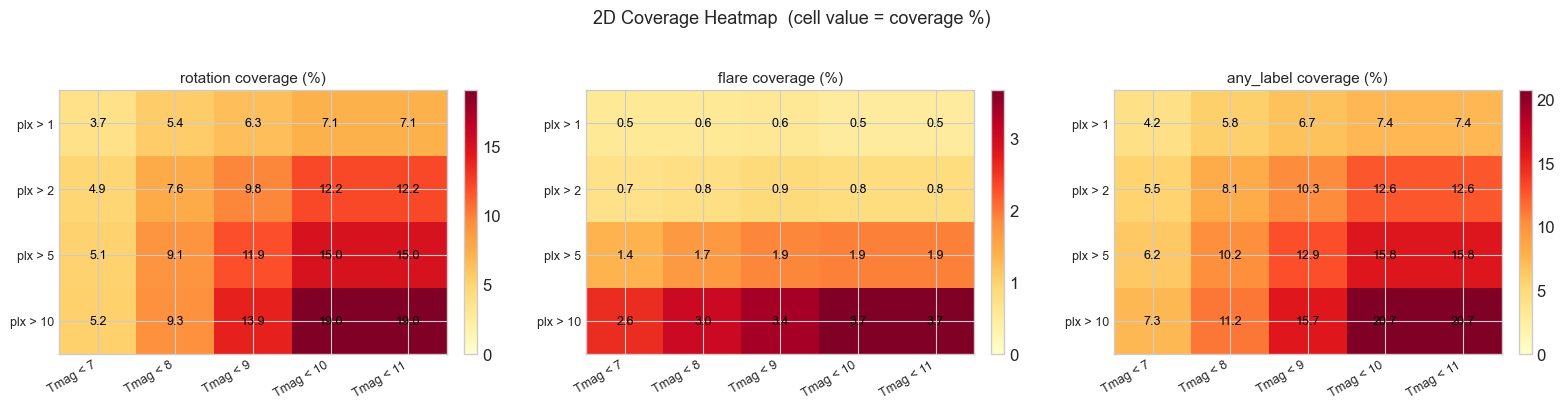

Sample sizes (N stars):
          Tmag < 7  Tmag < 8  Tmag < 9  Tmag < 10  Tmag < 11
plx > 1      39699    104905    256801     594649     594689
plx > 2      29957     75148    165874     349778     349798
plx > 5      15504     33665     72638     139197     139202
plx > 10      7113     14860     26408      41221      41222


In [7]:
TMAG_GRID = [7, 8, 9, 10, 11]
PLX_GRID  = [1, 2, 5, 10]

# Build matrices: rows = plx cutoff (reversed so larger plx = top), cols = Tmag cutoff
n_size_mat  = np.zeros((len(PLX_GRID), len(TMAG_GRID)), dtype=int)
rot_mat     = np.zeros((len(PLX_GRID), len(TMAG_GRID)))
flare_mat   = np.zeros((len(PLX_GRID), len(TMAG_GRID)))
any_mat     = np.zeros((len(PLX_GRID), len(TMAG_GRID)))

for ri, plx_cut in enumerate(PLX_GRID):
    for ci, tmag_cut in enumerate(TMAG_GRID):
        sub = df_labeled[(df_labeled['Tmag'] < tmag_cut) & (df_labeled['plx'] > plx_cut)]
        n = len(sub)
        n_size_mat[ri, ci] = n
        if n > 0:
            rot_mat[ri, ci]   = 100 * sub['rotation'].sum()   / n
            flare_mat[ri, ci] = 100 * sub['flare_ever'].sum() / n
            any_mat[ri, ci]   = 100 * sub['any_label'].sum()  / n

# Row labels: plx cutoffs reversed so stricter (larger) plx is at the top
row_labels = [f'plx > {p}' for p in PLX_GRID]
col_labels = [f'Tmag < {t}' for t in TMAG_GRID]

def _annotate(ax, mat, fmt='.1f'):
    for ri in range(mat.shape[0]):
        for ci in range(mat.shape[1]):
            ax.text(ci, ri, f'{mat[ri, ci]:{fmt}}',
                    ha='center', va='center', fontsize=9,
                    color='white' if mat[ri, ci] > 50 else 'black')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
titles = ['rotation coverage (%)', 'flare coverage (%)', 'any_label coverage (%)']
matrices = [rot_mat, flare_mat, any_mat]

for ax, title, mat in zip(axes, titles, matrices):
    im = ax.imshow(mat, aspect='auto', cmap='YlOrRd', vmin=0, vmax=max(mat.max(), 1))
    _annotate(ax, mat)
    ax.set_xticks(range(len(TMAG_GRID)))
    ax.set_xticklabels(col_labels, rotation=30, ha='right', fontsize=9)
    ax.set_yticks(range(len(PLX_GRID)))
    ax.set_yticklabels(row_labels, fontsize=9)
    ax.set_title(title, fontsize=11)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('2D Coverage Heatmap  (cell value = coverage %)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Also print sample sizes
print("Sample sizes (N stars):")
df_size = pd.DataFrame(n_size_mat, index=row_labels, columns=col_labels)
print(df_size.to_string())

---
## Section 7 — SPOC 2-min Coverage Estimate

For each Tmag bin, spot-check 30 random stars for SPOC 2-min data availability. Establishes whether expanding Tmag means switching pipelines.

In [8]:
import threading
import lightkurve as lk
from astroquery.mast import Observations

SPOC_SAMPLE_N   = 30
SPOC_SLEEP      = 0.5
QUERY_TIMEOUT   = 20
THREAD_TIMEOUT  = 25

Observations.TIMEOUT = QUERY_TIMEOUT

def _search_spoc(tic_id: int, timeout: int = THREAD_TIMEOUT):
    """Returns (has_spoc: bool, status: str)."""
    result = [False]
    exc    = [None]
    def _run():
        try:
            sr = lk.search_lightcurve(f"TIC {tic_id}", mission="TESS", author="SPOC", exptime=120)
            result[0] = len(sr) > 0
        except Exception as e:
            exc[0] = e
    t = threading.Thread(target=_run, daemon=True)
    t.start()
    t.join(timeout)
    if t.is_alive():
        return False, "timeout"
    if exc[0] is not None:
        return False, f"error:{type(exc[0]).__name__}"
    return result[0], "ok"

# Tmag < 7 ground truth from df_final (we know these were SPOC-checked)
spoc_rows = [{
    'Tmag_bin':    'Tmag < 7 (ground truth)',
    'n_sampled':   len(df_final),
    'n_spoc':      int((df_final['n_sectors'] >= 1).sum()),
    'spoc_pct':    round(100 * (df_final['n_sectors'] >= 1).mean(), 1),
    'note':        'exact (full df_final)',
}]

# Bins 7–8, 8–9, 9–10, 10–11 — spot-check 30 random stars each
rng = np.random.default_rng(42)
spoc_bins = [(7, 8), (8, 9), (9, 10), (10, 11)]

for lo, hi in spoc_bins:
    pool = df_labeled[(df_labeled['Tmag'] >= lo) & (df_labeled['Tmag'] < hi) &
                      (df_labeled['plx'] > 1.0)]
    if len(pool) == 0:
        spoc_rows.append({'Tmag_bin': f'Tmag [{lo},{hi})', 'n_sampled': 0, 'n_spoc': 0,
                          'spoc_pct': float('nan'), 'note': 'no stars in bin'})
        continue

    sample = pool.sample(n=min(SPOC_SAMPLE_N, len(pool)), random_state=42)
    n_has  = 0
    n_ok   = 0

    print(f"Bin Tmag [{lo},{hi}) — checking {len(sample)} stars for SPOC 2-min...")
    for _, row in sample.iterrows():
        tic_id = int(row['ID'])
        has_spoc, status = _search_spoc(tic_id)
        if status == "ok":
            n_ok += 1
            if has_spoc:
                n_has += 1
        else:
            print(f"  TIC {tic_id}: {status}")
        time.sleep(SPOC_SLEEP)

    pct = round(100 * n_has / n_ok, 1) if n_ok > 0 else float('nan')
    spoc_rows.append({
        'Tmag_bin':  f'Tmag [{lo},{hi})',
        'n_sampled': len(sample),
        'n_spoc':    n_has,
        'spoc_pct':  pct,
        'note':      f'{SPOC_SAMPLE_N}-star spot check (est.)',
    })
    print(f"  -> {n_has}/{n_ok} have SPOC 2-min  ({pct}%)")

df_spoc = pd.DataFrame(spoc_rows)
print("\nSPOC 2-min availability estimate:")
print(df_spoc.to_string(index=False))

Bin Tmag [7,8) — checking 30 stars for SPOC 2-min...


No data found for target "TIC 137151099".
No data found for target "TIC 178276661".
No data found for target "TIC 114921119".
No data found for target "TIC 192785222".
No data found for target "TIC 154007056".
No data found for target "TIC 71331029".
No data found for target "TIC 446531937".
No data found for target "TIC 71549007".
No data found for target "TIC 234997574".
No data found for target "TIC 442963607".
No data found for target "TIC 1884273515".
No data found for target "TIC 298434448".
No data found for target "TIC 300664928".
No data found for target "TIC 176403070".
No data found for target "TIC 257554881".
No data found for target "TIC 327036243".
No data found for target "TIC 123057128".
No data found for target "TIC 304920136".
No data found for target "TIC 351871062".
No data found for target "TIC 450299030".
No data found for target "TIC 99558548".
No data found for target "TIC 459419685".
No data found for target "TIC 180298524".
No data found for target "TIC 221543

  -> 6/30 have SPOC 2-min  (20.0%)
Bin Tmag [8,9) — checking 30 stars for SPOC 2-min...


No data found for target "TIC 305830830".
No data found for target "TIC 132229908".
No data found for target "TIC 330312152".
No data found for target "TIC 335802776".
No data found for target "TIC 77910085".
No data found for target "TIC 38897329".
No data found for target "TIC 207507344".
No data found for target "TIC 265580421".
No data found for target "TIC 42245441".
No data found for target "TIC 373942114".
No data found for target "TIC 287759907".
No data found for target "TIC 466851801".
No data found for target "TIC 326670785".
No data found for target "TIC 305143548".
No data found for target "TIC 172222358".
No data found for target "TIC 170757461".
No data found for target "TIC 325772377".
No data found for target "TIC 257884501".
No data found for target "TIC 205820277".


  -> 11/30 have SPOC 2-min  (36.7%)
Bin Tmag [9,10) — checking 30 stars for SPOC 2-min...


No data found for target "TIC 58870807".
No data found for target "TIC 360604523".
No data found for target "TIC 367429769".
No data found for target "TIC 386259055".
No data found for target "TIC 393718649".
No data found for target "TIC 420204404".
No data found for target "TIC 357813086".
No data found for target "TIC 14959820".
No data found for target "TIC 128079746".
No data found for target "TIC 452926243".
No data found for target "TIC 281684617".
No data found for target "TIC 288495447".
No data found for target "TIC 367289982".
No data found for target "TIC 399909576".
No data found for target "TIC 747063665".
No data found for target "TIC 196216366".
No data found for target "TIC 350970151".
No data found for target "TIC 32145593".
No data found for target "TIC 53870643".
No data found for target "TIC 240641058".
No data found for target "TIC 334117877".
No data found for target "TIC 180271251".
No data found for target "TIC 197746814".
No data found for target "TIC 36345829

  -> 6/30 have SPOC 2-min  (20.0%)
Bin Tmag [10,11) — checking 30 stars for SPOC 2-min...


No data found for target "TIC 124984811".
No data found for target "TIC 374265024".
No data found for target "TIC 393278307".
No data found for target "TIC 126761039".
No data found for target "TIC 248732431".
No data found for target "TIC 32475893".
No data found for target "TIC 382463857".
No data found for target "TIC 453426148".
No data found for target "TIC 68082065".
No data found for target "TIC 161661994".
No data found for target "TIC 419871775".
No data found for target "TIC 437604671".
No data found for target "TIC 100625718".
No data found for target "TIC 92128241".
No data found for target "TIC 5130524".
No data found for target "TIC 241575284".
No data found for target "TIC 31587986".
No data found for target "TIC 67399228".
No data found for target "TIC 230300703".
No data found for target "TIC 35026016".
No data found for target "TIC 349235760".
No data found for target "TIC 408162594".
No data found for target "TIC 469046537".
No data found for target "TIC 141008431".


  -> 5/30 have SPOC 2-min  (16.7%)

SPOC 2-min availability estimate:
               Tmag_bin  n_sampled  n_spoc  spoc_pct                      note
Tmag < 7 (ground truth)       6654    6654     100.0     exact (full df_final)
             Tmag [7,8)         30       6      20.0 30-star spot check (est.)
             Tmag [8,9)         30      11      36.7 30-star spot check (est.)
            Tmag [9,10)         30       6      20.0 30-star spot check (est.)
           Tmag [10,11)         30       5      16.7 30-star spot check (est.)


---
## Section 8 — Summary & Recommendation

In [9]:
# Candidate boundaries to evaluate
candidates = [
    ('Tmag<7,  plx>10', 7,  10),
    ('Tmag<9,  plx>5',  9,  5),
    ('Tmag<9,  plx>2',  9,  2),
    ('Tmag<10, plx>5',  10, 5),
    ('Tmag<10, plx>2',  10, 2),
    ('Tmag<11, plx>5',  11, 5),
    ('Tmag<11, plx>2',  11, 2),
    ('Tmag<11, plx>1',  11, 1),
]

# Build SPOC lookup from df_spoc for the estimate column
spoc_lookup: dict[str, str] = {}
for _, row in df_spoc.iterrows():
    bin_str = row['Tmag_bin']
    pct_str = f"~{row['spoc_pct']}%" if not pd.isna(row['spoc_pct']) else '?'
    spoc_lookup[bin_str] = pct_str

def _spoc_est(tmag_cut: int) -> str:
    if tmag_cut <= 7:
        return spoc_lookup.get('Tmag < 7 (ground truth)', '~100%')
    # Use the highest bin that is fully within the cutoff
    best = '?'
    for lo, hi in [(7, 8), (8, 9), (9, 10), (10, 11)]:
        if hi <= tmag_cut:
            key = f'Tmag [{lo},{hi})'
            best = spoc_lookup.get(key, '?')
    return best

summary_rows = []
for label, tmag_cut, plx_cut in candidates:
    sub = df_labeled[(df_labeled['Tmag'] < tmag_cut) & (df_labeled['plx'] > plx_cut)]
    n = len(sub)
    if n == 0:
        continue
    summary_rows.append({
        'Candidate boundary': label,
        'N stars':      f'{n:,}',
        'rotation%':    f"{100*sub['rotation'].sum()/n:.1f}%",
        'flare%':       f"{100*sub['flare_ever'].sum()/n:.1f}%",
        'transit%':     f"{100*sub['transit'].sum()/n:.1f}%",
        'any_label%':   f"{100*sub['any_label'].sum()/n:.1f}%",
        'SPOC avail?':  _spoc_est(tmag_cut),
    })

df_summary = pd.DataFrame(summary_rows)
print("=" * 90)
print("Decision Table — Candidate Sample Boundaries")
print("=" * 90)
print(df_summary.to_string(index=False))
print("=" * 90)

Decision Table — Candidate Sample Boundaries
Candidate boundary N stars rotation% flare% transit% any_label% SPOC avail?
   Tmag<7,  plx>10   7,113      5.2%   2.6%     0.4%       7.3%     ~100.0%
    Tmag<9,  plx>5  72,638     11.9%   1.9%     0.5%      12.9%      ~36.7%
    Tmag<9,  plx>2 165,874      9.8%   0.9%     0.2%      10.3%      ~36.7%
    Tmag<10, plx>5 139,197     15.0%   1.9%     0.5%      15.8%      ~20.0%
    Tmag<10, plx>2 349,778     12.2%   0.8%     0.3%      12.6%      ~20.0%
    Tmag<11, plx>5 139,202     15.0%   1.9%     0.5%      15.8%      ~16.7%
    Tmag<11, plx>2 349,798     12.2%   0.8%     0.3%      12.6%      ~16.7%
    Tmag<11, plx>1 594,689      7.1%   0.5%     0.2%       7.4%      ~16.7%


## Decision

*(Fill in after reviewing the table above)*

**Chosen boundary:** `Tmag < ???, plx > ??? mas`

**Rationale:**
- N stars: ???
- any_label%: ???%  (target ≥ 20%)
- SPOC 2-min availability: ???%
- Notes: